In [1]:
"""
Visualize annotations overlaid on an image, side-by-side with the raw image.

Supports two annotation formats:
  1. DeepForest CSV  (image_path, xmin, ymin, xmax, ymax, label, ...)
  2. COCO JSON       (standard COCO object-detection format)

Usage examples:
  # CSV annotations
  python visualize_annotations.py \
      --image ../data/2024_08_2.png \
      --annotations ../sample_data/annotations/master_train.csv \
      --format csv

  # COCO JSON annotations
  python visualize_annotations.py \
      --image ../data/2024_08_2.png \
      --annotations ../data/2024_08_2.json \
      --format coco

  # Save to file instead of displaying
  python visualize_annotations.py \
      --image ../data/2024_08_2.png \
      --annotations ../data/2024_08_2.json \
      --format coco \
      --output comparison.png
"""

'\nVisualize annotations overlaid on an image, side-by-side with the raw image.\n\nSupports two annotation formats:\n  1. DeepForest CSV  (image_path, xmin, ymin, xmax, ymax, label, ...)\n  2. COCO JSON       (standard COCO object-detection format)\n\nUsage examples:\n  # CSV annotations\n  python visualize_annotations.py       --image ../data/2024_08_2.png       --annotations ../sample_data/annotations/master_train.csv       --format csv\n\n  # COCO JSON annotations\n  python visualize_annotations.py       --image ../data/2024_08_2.png       --annotations ../data/2024_08_2.json       --format coco\n\n  # Save to file instead of displaying\n  python visualize_annotations.py       --image ../data/2024_08_2.png       --annotations ../data/2024_08_2.json       --format coco       --output comparison.png\n'

In [22]:
import argparse
import json
import os
import sys

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import pandas as pd
from PIL import Image

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Gill Sans MT']

In [27]:

def load_csv_annotations(csv_path: str, image_path: str) -> pd.DataFrame:
    """Load DeepForest-style CSV and filter to the target image."""
    df = pd.read_csv(csv_path)
    image_basename = os.path.basename(image_path)

    # Filter rows matching this image
    if "image_path" in df.columns:
        df = df[df["image_path"] == image_basename].copy()

    required = {"xmin", "ymin", "xmax", "ymax"}
    if not required.issubset(df.columns):
        raise ValueError(
            f"CSV must contain columns {required}. Found: {list(df.columns)}"
        )

    if "label" not in df.columns:
        df["label"] = "Tree"

    return df[["xmin", "ymin", "xmax", "ymax", "label"]].reset_index(drop=True)


In [26]:
def load_coco_annotations(json_path: str, image_path: str) -> pd.DataFrame:
    """Load COCO JSON and convert to a DeepForest-style DataFrame."""
    with open(json_path, "r") as f:
        coco = json.load(f)

    # Build category lookup
    cat_map = {c["id"]: c["name"] for c in coco.get("categories", [])}

    # Find the image entry matching our file
    image_basename = os.path.basename(image_path)
    image_id = None
    for img in coco.get("images", []):
        if img["file_name"] == image_basename:
            image_id = img["id"]
            break

    if image_id is None:
        # If only one image in the JSON, use it regardless of name
        if len(coco.get("images", [])) == 1:
            image_id = coco["images"][0]["id"]
            print(f"[INFO] Image name mismatch; using sole entry (id={image_id}).")
        else:
            raise ValueError(
                f"Image '{image_basename}' not found in COCO JSON. "
                f"Available: {[i['file_name'] for i in coco.get('images', [])]}"
            )

    # Convert COCO [x, y, w, h] -> DeepForest [xmin, ymin, xmax, ymax]
    rows = []
    for ann in coco["annotations"]:
        if ann["image_id"] != image_id:
            continue
        x, y, w, h = ann["bbox"]
        label = cat_map.get(ann["category_id"], "Tree")
        rows.append({
            "xmin": x,
            "ymin": y,
            "xmax": x + w,
            "ymax": y + h,
            "label": label.capitalize(),
        })

    if not rows:
        print("[WARNING] No annotations found for this image.")

    return pd.DataFrame(rows)


In [25]:
def draw_overlay(ax, image: np.ndarray, df: pd.DataFrame, title: str = "Annotated", linewidth: float = 1.5, color: str = "red"):
    """Draw bounding boxes on an image axis."""
    ax.imshow(image)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.axis("off")

    # Color: fixed color or per-class colormap
    unique_labels = df["label"].unique() if len(df) > 0 else []
    if color == "auto":
        cmap = plt.cm.get_cmap("tab10", max(len(unique_labels), 1))
        label_colors = {label: cmap(i) for i, label in enumerate(unique_labels)}
    else:
        label_colors = {label: color for label in unique_labels}

    for _, row in df.iterrows():
        color = label_colors.get(row["label"], (0, 1, 0, 1))
        rect = patches.Rectangle(
            (row["xmin"], row["ymin"]),
            row["xmax"] - row["xmin"],
            row["ymax"] - row["ymin"],
            linewidth=linewidth,
            edgecolor=color,
            facecolor="none",
        )
        ax.add_patch(rect)

    # Legend
    if len(unique_labels) > 0:
        legend_patches = [
            patches.Patch(facecolor=label_colors[l], edgecolor=label_colors[l], label=l)
            for l in unique_labels
        ]
        ax.legend(
            handles=legend_patches, loc="upper right",
            fontsize=12, framealpha=0.7,
        )

In [ ]:
def visualize_side_by_side(
    image_path: str,
    annotations_path: str,
    fmt: str = "csv",
    linewidth: float = 1.5,
    color: str = "red",
    output_path: str | None = None,
    figsize: tuple = (20, 10),
):
    """Produce a side-by-side comparison of raw vs annotated image."""
    # Load image
    image = np.array(Image.open(image_path))

    # Load annotations
    if fmt == "csv":
        df = load_csv_annotations(annotations_path, image_path)
    elif fmt == "coco":
        df = load_coco_annotations(annotations_path, image_path)
    else:
        raise ValueError(f"Unsupported format '{fmt}'. Use 'csv' or 'coco'.")

    print(f"Loaded {len(df)} annotations for {os.path.basename(image_path)}")

    # Create side-by-side figure
    fig, (ax_raw, ax_ann) = plt.subplots(1, 2, figsize=figsize)

    # Left: raw image
    ax_raw.imshow(image)
    ax_raw.set_title("Raw Image", fontsize=14, fontweight="bold")
    ax_raw.axis("off")

    # Right: annotated image
    draw_overlay(ax_ann, image, df, title=f"Annotated ({len(df)} bounding boxes)", linewidth=linewidth, color=color)

    fig.suptitle(
        os.path.basename(image_path),
        fontsize=16, y=0.98,
    )
    plt.tight_layout()

    if output_path:
        fig.savefig(output_path, dpi=150, bbox_inches="tight", facecolor="white")
        print(f"Saved to {output_path}")
    else:
        plt.show()

    plt.close(fig)

Loaded 155 annotations for 2024_08_372.png


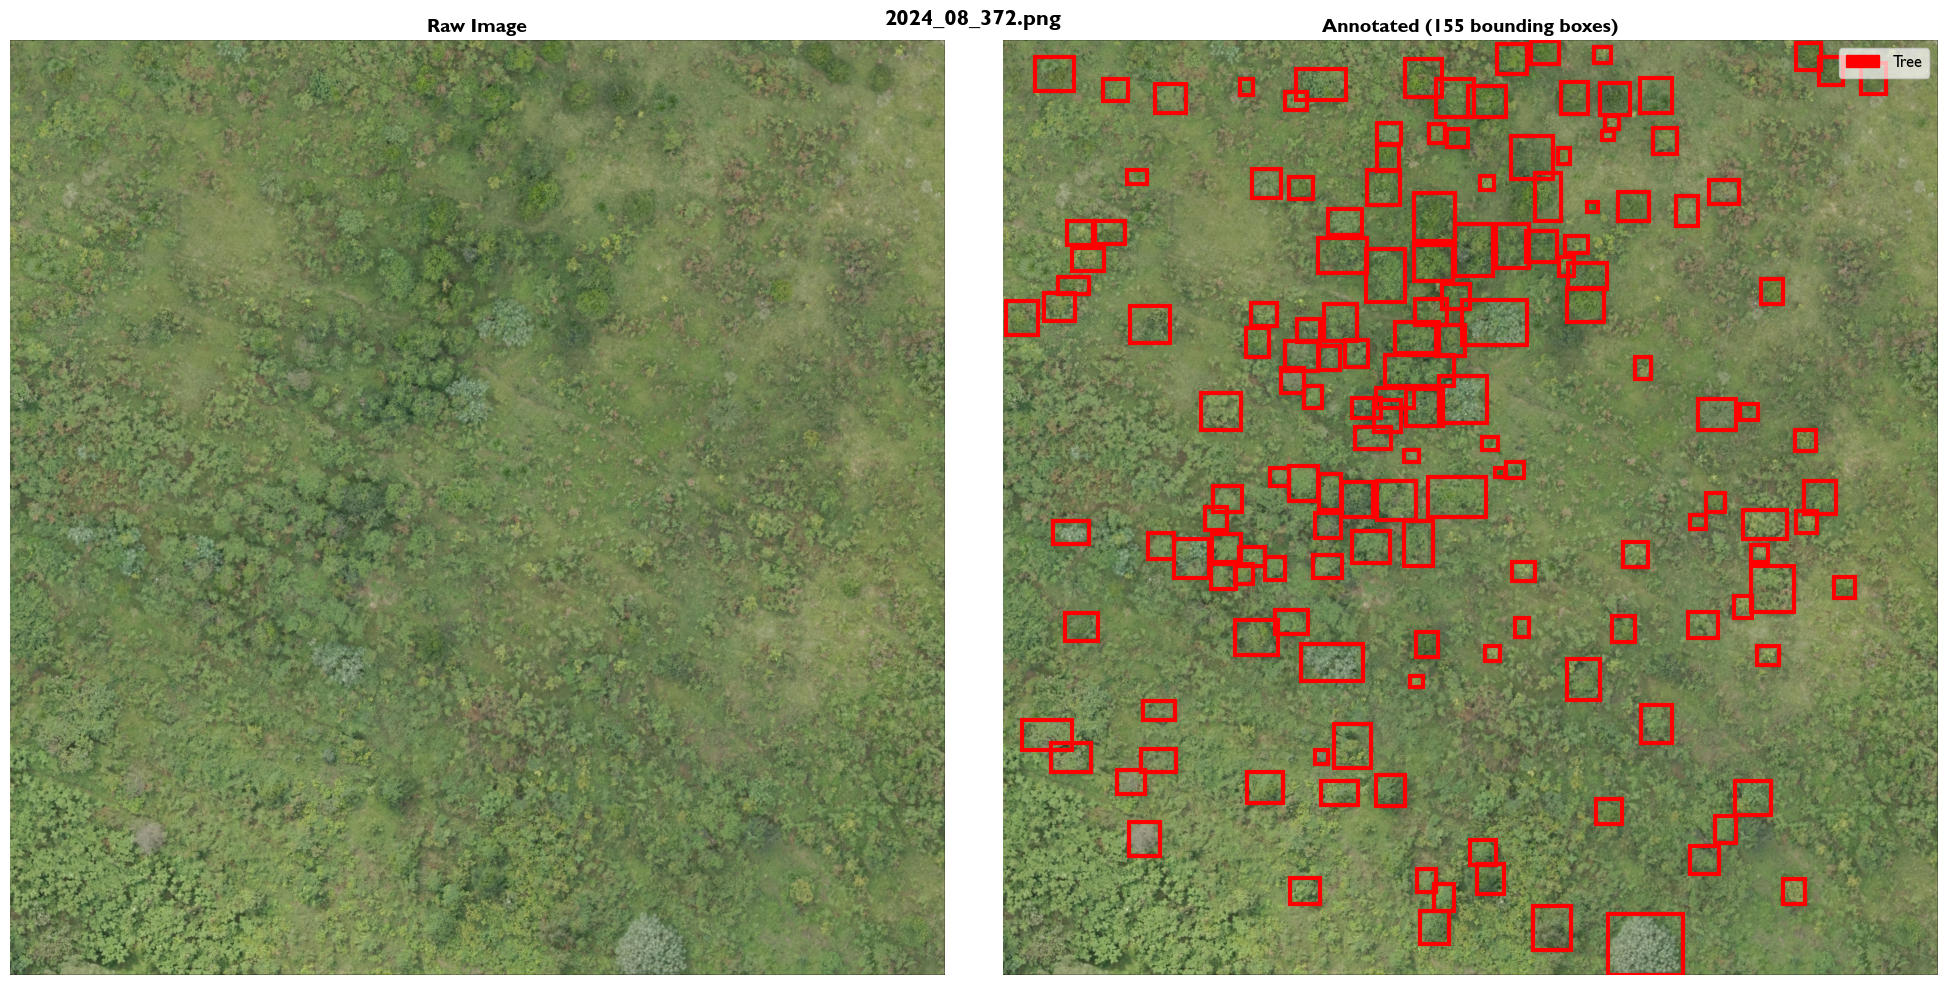

In [29]:
image = "2024_08_372.png"
csv_file = "2024_08_372.csv"
fmt = "csv"

visualize_side_by_side(
    image_path=image,
    annotations_path=csv_file,
    fmt=fmt,
    linewidth=3
)

In [ ]:
if __name__ == "__main__":
    parser = argparse.ArgumentParser(
        description="Side-by-side visualization of raw vs annotated image."
    )
    parser.add_argument(
        "--image", required=True,
        help="Path to the image file (e.g. ../data/2024_08_2.png)",
    )
    parser.add_argument(
        "--annotations", required=True,
        help="Path to annotations file (CSV or COCO JSON)",
    )
    parser.add_argument(
        "--format", choices=["csv", "coco"], default="csv",
        help="Annotation format: 'csv' (DeepForest CSV) or 'coco' (COCO JSON)",
    )
    parser.add_argument(
        "--output", default=None,
        help="Output file path. If omitted, displays interactively.",
    )
    parser.add_argument(
        "--figsize", type=int, nargs=2, default=[20, 10],
        help="Figure size as width height (default: 20 10)",
    )
    args = parser.parse_args()

    visualize_side_by_side(
        image_path=args.image,
        annotations_path=args.annotations,
        fmt=args.format,
        output_path=args.output,
        figsize=tuple(args.figsize),
    )